In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
df = pd.read_csv("/content/Crash_Reporting_-_Non-Motorists_Data_20260310.csv")
df['ACRS Report Type']

,ACRS Report Type
0,Fatal Crash
1,Injury Crash
2,Injury Crash
3,Injury Crash
4,Injury Crash
...,...
7126,Injury Crash
7127,Injury Crash
7128,Injury Crash
7129,Injury Crash


In [ ]:
df['Road Name'] = df['Road Name'].fillna('Unknown Road')

In [ ]:
df['Is Fatal'] = df['ACRS Report Type'].str.upper().str.contains('FATAL').astype(int)


,Report Number,Local Case Number,Agency Name,ACRS Report Type,Crash Date/Time,Route Type,Road Name,Cross-Street Name,Off-Road Description,Municipality,Related Non-Motorist,Collision Type,Weather,Surface Condition,Light,Traffic Control,Driver Substance Abuse,Non-Motorist Substance Abuse,Person ID,Pedestrian Type,Pedestrian Movement,Pedestrian Actions,Pedestrian Location,At Fault,Injury Severity,Safety Equipment,Latitude,Longitude,Location,Is Fatal
0,MCP26350094,260009207,MONTGOMERY,Fatal Crash,03/01/2026 06:30:00 PM,Municipality Route,AVERY RD,NORBECK RD,NaN,NaN,Pedestrian,Single Vehicle,Clear,Dry,Dark - Lighted,Traffic Control Signal,"Not Suspect of Alcohol Use, Not Suspect of Dru...","Unknown, Not Suspect of Drug Use",FF8C713D-2E63-4FBB-B170-6A810FF03738,Pedestrian,Unknown,Unknown,Unknown,No,Fatal Injury,NaN,39.092816,-77.122717,"(39.09281566, -77.12271671)",1
1,MCP2460002K,260009046,MONTGOMERY,Injury Crash,02/28/2026 05:14:00 PM,NaN,NaN,NaN,Parking Lot Way PARKING LOT WAY OF 9651...,NaN,Pedestrian,Single Vehicle,Clear,NaN,Daylight,NaN,"Not Suspect of Alcohol Use, Not Suspect of Dru...","Not Suspect of Alcohol Use, Not Suspect of Dru...",A48CDA52-1420-4987-B9B2-1D99B88EE12D,Pedestrian,Other,None (No Improper Action),Other,No,Possible Injury,NaN,39.153768,-77.197923,"(39.15376787, -77.19792279)",0
2,MCP2460002K,260009046,MONTGOMERY,Injury Crash,02/28/2026 05:14:00 PM,NaN,NaN,NaN,Parking Lot Way PARKING LOT WAY OF 9651...,NaN,Pedestrian,Single Vehicle,Clear,NaN,Daylight,NaN,"Not Suspect of Alcohol Use, Not Suspect of Dru...","Not Suspect of Alcohol Use, Not Suspect of Dru...",CACA12EB-BE7F-482C-90E2-99434752A55B,Pedestrian,Other,None (No Improper Action),Other,No,Possible Injury,NaN,39.153768,-77.197923,"(39.15376787, -77.19792279)",0
3,MCP2460002K,260009046,MONTGOMERY,Injury Crash,02/28/2026 05:14:00 PM,NaN,NaN,NaN,Parking Lot Way PARKING LOT WAY OF 9651...,NaN,Pedestrian,Single Vehicle,Clear,NaN,Daylight,NaN,"Not Suspect of Alcohol Use, Not Suspect of Dru...","Not Suspect of Alcohol Use, Not Suspect of Dru...",71E3FA30-F542-4651-98C9-42528C80E8D4,Pedestrian,Other,None (No Improper Action),Other,No,Suspected Minor Injury,NaN,39.153768,-77.197923,"(39.15376787, -77.19792279)",0
4,MCP316300B4,260008758,MONTGOMERY,Injury Crash,02/26/2026 06:27:00 PM,Maryland (State) Route,PLYERS MILL RD,CONNECTICUT AVE,NaN,NaN,Scooter (electric),Single Vehicle,Rain,Wet,Dark - Lighted,Traffic Control Signal,"Not Suspect of Alcohol Use, Not Suspect of Dru...","Not Suspect of Alcohol Use, Not Suspect of Dru...",15F0DAA4-8477-4C03-8DA9-20A326AEC57D,Scooter (electric),Walking/Cycling on Sidewalk,"Not Visible (Dark Clothing, No Lighting, etc.)",Intersection Marked Crosswalk,No,Suspected Minor Injury,NaN,39.029758,-77.075770,"(39.0297585, -77.07576983)",0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7126,MCP9379000G,15000697,Montgomery County Police,Injury Crash,01/05/2015 12:23:00 PM,Maryland (State),FREDERICK RD,KING FARM BLVD,NaN,ROCKVILLE,PEDESTRIAN,HEAD ON LEFT TURN,CLEAR,DRY,DAYLIGHT,TRAFFIC SIGNAL,NaN,NONE DETECTED,FDEDF7D9-E358-49EC-9552-FA61069E098A,PEDESTRIAN,Cross/Enter at Intersection,NO IMPROPER ACTIONS,ON ROADWAY AT CROSSWALK,NaN,POSSIBLE INJURY,NaN,39.116905,-77.168492,"(39.116905, -77.16849167)",0
7127,MCP27650015,15000583,Montgomery County Police,Injury Crash,01/04/2015 02:55:00 PM,NaN,NaN,NaN,Parking lot of Giant Food (12051 Rockville Pike),NaN,PEDESTRIAN,SINGLE VEHICLE,RAINING,NaN,DAYLIGHT,NO CONTROLS,NONE DETECTED,NONE DETECTED,B0192567-A332-44AA-B745-26DEC4046E9B,PEDESTRIAN,Cross/Enter at Intersection,NO IMPROPER ACTIONS,ON ROADWAY AT CROSSWALK,NaN,POSSIBLE INJURY,NONE,38.962827,-77.087983,"(38.96282667, -77.08798333)",0
7128,MCP2690000N,15000473,Montgomery County Police,Injury Crash,01/03/2015 08:31:00 PM,NaN,NaN,NaN,Parking Lot 13 at 11219 Grandview Ave,NaN,PEDESTRIAN,SINGLE VEHICLE,RAINING,NaN,DARK LIGHTS ON,NO CONTROLS,ALCOHOL CONTRIBUTED,NONE DETECTE

In [ ]:
import pandas as pd


df['Road Name'] = df['Road Name'].fillna('Unknown Road').astype(str).str.strip()

def check_substance(x):
    x_upper = str(x).upper().strip()
    if ('ALCOHOL' in x_upper or 'DRUG' in x_upper) and ('NOT SUSPECT' not in x_upper):
        return 'SUBSTANCE_INVOLVED'
    else:
        return 'NONE_DETECTED'

df['Substance Abuse Flag'] = df['Driver Substance Abuse'].apply(check_substance)


df['Clean_Report_Type'] = df['ACRS Report Type'].fillna('').astype(str).str.upper().str.strip()
df['Is Fatal'] = df['Clean_Report_Type'].str.contains('FATAL').astype(int)
df['Is Substance Involved'] = (df['Substance Abuse Flag'] == 'SUBSTANCE_INVOLVED').astype(int)

summary_df = df.groupby('Road Name').agg(
    Total_Crashes=('Road Name', 'count'),
    Fatal_Crashes=('Is Fatal', 'sum'),
    Substance_Involved_Crashes=('Is Substance Involved', 'sum')
).reset_index()

summary_df['Percent_Fatal'] = (summary_df['Fatal_Crashes'].astype(float) / summary_df['Total_Crashes'].astype(float)) * 100
summary_df['Percent_Non_Fatal'] = 100.0 - summary_df['Percent_Fatal']
summary_df['Avg_Substance_Involved'] = summary_df['Substance_Involved_Crashes'].astype(float) / summary_df['Total_Crashes'].astype(float)



In [ ]:
summary_df.sort_values(by='Percent_Fatal', ascending=False)[:30]

,Road Name,Total_Crashes,Fatal_Crashes,Substance_Involved_Crashes,Percent_Fatal,Percent_Non_Fatal,Avg_Substance_Involved
240,COPLEY PLACE,1,1,0,100.000000,0.000000,0.000000
32,ASBURY DRIVE,1,1,0,100.000000,0.000000,0.000000
521,HIGH POINT DR,1,1,0,100.000000,0.000000,0.000000
36,ASPEN HILL RD (SB/L),1,1,0,100.000000,0.000000,0.000000
704,MILLWOOD RD,1,1,0,100.000000,0.000000,0.000000
79,BELLS MILL RD,1,1,0,100.000000,0.000000,0.000000
1014,SNOUFFER SCHOOL ROAD,1,1,0,100.000000,0.000000,0.000000
46,AVERY RD,1,1,0,100.000000,0.000000,0.000000
679,MCAULIFFE DR,1,1,0,100.000000,0.000000,0.000000
762,NORBECK RD (WB/L),1,1,0,100.000000,0.000000,0.000000


In [ ]:
summary_df = summary_df[summary_df['Total_Crashes'] > 5]

summary_df.sort_values(by='Percent_Fatal', ascending=False).reset_index(drop=True)

,Road Name,Total_Crashes,Fatal_Crashes,Substance_Involved_Crashes,Percent_Fatal,Percent_Non_Fatal,Avg_Substance_Involved
0,GROSVENOR LA,8,3,0,37.500000,62.500000,0.000000
1,VEIRS MILL RD (WB/L),9,3,0,33.333333,66.666667,0.000000
2,NORBECK RD,8,2,0,25.000000,75.000000,0.000000
3,BEALL AVE #2,10,2,0,20.000000,80.000000,0.000000
4,MIDCOUNTY HWY,11,2,0,18.181818,81.818182,0.000000
...,...,...,...,...,...,...,...
174,WILLARD AVE,11,0,0,0.000000,100.000000,0.000000
175,WISCONSIN AVE,73,0,1,0.000000,100.000000,0.013699
176,WILSON LA,7,0,0,0.000000,100.000000,0.000000
177,WOODMONT AVE,32,0,0,0.000000,100.000000,0.000000


In [ ]:
X = summary_df.set_index('Road Name')


X = X.drop(columns=['Fatal_Crashes', 'Substance_Involved_Crashes', 'Percent_Non_Fatal'])
X

,Total_Crashes,Percent_Fatal,Avg_Substance_Involved
Road Name,,,
16TH ST,24,0.000000,0.000000
AMHERST AVE,19,0.000000,0.000000
ARCOLA AVE,21,0.000000,0.000000
ARLINGTON RD,16,0.000000,0.000000
ASPEN HILL RD,28,0.000000,0.035714
...,...,...,...
WISCONSIN AVE,73,0.000000,0.013699
WISTERIA DR,13,7.692308,0.000000
WOODFIELD RD,25,4.000000,0.000000


In [ ]:
top_10_high_volume = X.sort_values(by='Total_Crashes', ascending=False).head(10)

print(top_10_high_volume)

                   Total_Crashes  Percent_Fatal  Avg_Substance_Involved
Road Name                                                              
Unknown Road                1701       0.587889                0.012934
GEORGIA AVE                  324       4.320988                0.015432
ROCKVILLE PIKE               151       3.973510                0.006623
NEW HAMPSHIRE AVE            128       8.593750                0.039062
FREDERICK RD                 125       5.600000                0.016000
VEIRS MILL RD                 87      10.344828                0.011494
UNIVERSITY BLVD W             83       3.614458                0.012048
CONNECTICUT AVE               83       1.204819                0.012048
COLESVILLE RD                 78       1.282051                0.012821
RANDOLPH RD                   75       4.000000                0.000000


In [ ]:
import pandas as pd
import scipy.spatial

In [ ]:

X_norm = (X - X.min()) / (X.max() - X.min())

def find_similar_roads(target_road_name):
    target_road_name = target_road_name.upper().strip()

    if target_road_name not in X_norm.index:
        return f"Road '{target_road_name}' not found in the feature matrix."

    target_vector = X_norm.loc[target_road_name]


    distances = scipy.spatial.distance.cdist(X_norm, [target_vector], metric="euclidean")[:, 0]

    results = list(zip(X_norm.index, distances))


    top_results = sorted(results, key=lambda x: x[1])[1:11]

    print(f"\nTop 10 Roads most similar to: {target_road_name}")
    print(f"{'-'*75}")
    for name, score in top_results:
        print(f"{name:<50} | Distance/Score: {score:.4f}")
dangerous_queries = [
    "E GUDE DR",
    "ROCKVILLE PIKE",
    "NEW HAMPSHIRE AVE"
]

for road in dangerous_queries:
    find_similar_roads(road)


Top 10 Roads most similar to: E GUDE DR
---------------------------------------------------------------------------
HUNGERFORD DR                                      | Distance/Score: 0.0073
CHAPMAN AVE                                        | Distance/Score: 0.0150
E RANDOLPH RD                                      | Distance/Score: 0.0150
FREDERICK RD (SB/L)                                | Distance/Score: 0.0167
MONTROSE RD                                        | Distance/Score: 0.0167
TUCKERMAN LA                                       | Distance/Score: 0.0383
RIVER RD                                           | Distance/Score: 0.0489
PICCARD DR                                         | Distance/Score: 0.0530
UNIVERSITY BLVD E                                  | Distance/Score: 0.0558
MASSACHUSETTS AVE                                  | Distance/Score: 0.0586

Top 10 Roads most similar to: ROCKVILLE PIKE
---------------------------------------------------------------------------
U

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD

In [ ]:
wcss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(X_norm)
    wcss.append(kmeans.inertia_)

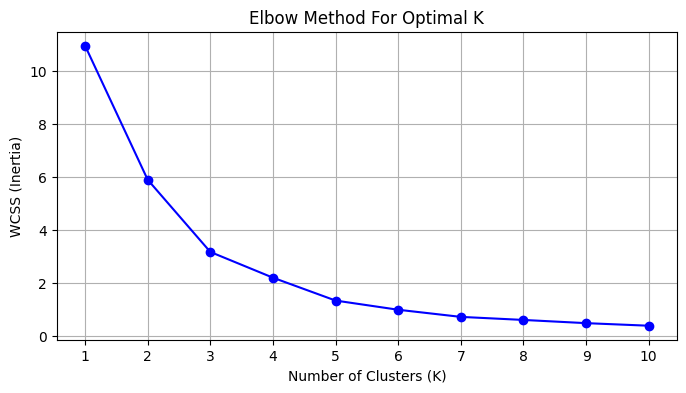

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(k_range, wcss, marker='o', color='b')
plt.title('Elbow Method For Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(k_range)
plt.grid(True)
plt.show()

In [ ]:
optimal_k = 3

kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', max_iter=300, n_init=10, random_state=42)
X_norm['Cluster'] = kmeans_final.fit_predict(X_norm)

print(f"\n--- Road Counts per Cluster (K={optimal_k}) ---")
print(X_norm['Cluster'].value_counts())


--- Road Counts per Cluster (K=3) ---
Cluster
1    141
0     26
2     12
Name: count, dtype: int64


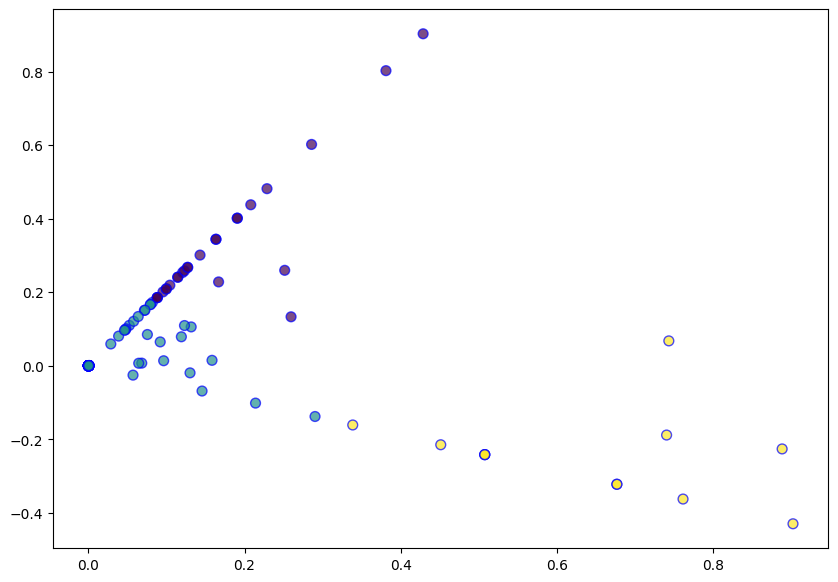

In [ ]:
features_only = X_norm.drop(columns=['Cluster'])

svd = TruncatedSVD(n_components=2, random_state=42)
svd_elements = svd.fit_transform(features_only)

svd_df = pd.DataFrame(data=svd_elements, columns=['SVD Component 1', 'SVD Component 2'])
svd_df['Cluster'] = X_norm['Cluster'].values
svd_df['Road Name'] = X_norm.index

plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    svd_df['SVD Component 1'],
    svd_df['SVD Component 2'],
    c=svd_df['Cluster'],
    cmap='viridis',
    alpha=0.7,
    edgecolors='b',
    s=50
)

In [ ]:
df_normalized = X_norm.copy()

features = list(df_normalized.columns)

kmeans_model = KMeans(n_clusters=3, random_state=42)
df_normalized['Cluster'] = kmeans_model.fit_predict(df_normalized[features])

<Axes: title={'center': 'Urban Clusters Visualized via SVD'}, xlabel='0', ylabel='1'>

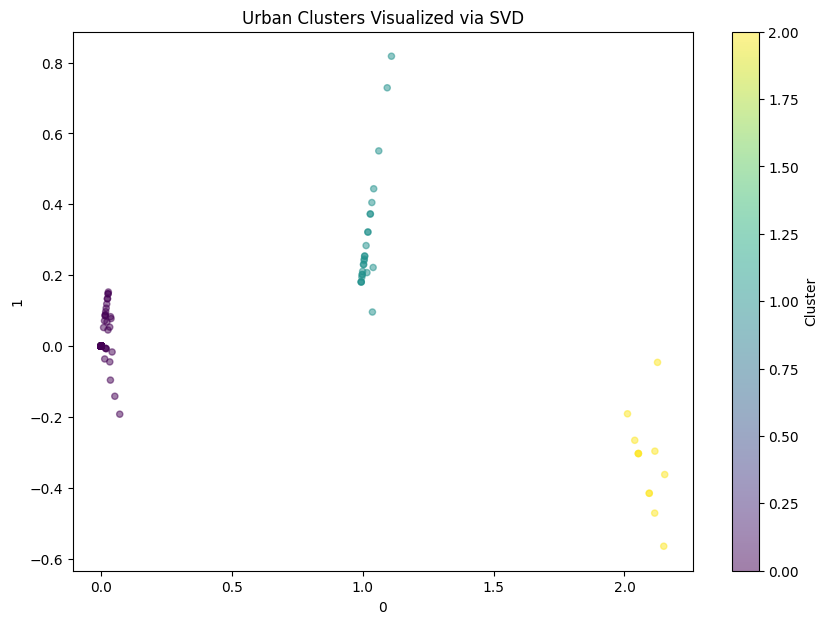

In [ ]:
dr_model = TruncatedSVD(n_components=2, random_state=42)
trans_data = dr_model.fit_transform(df_normalized[features])

plot_df = pd.DataFrame(trans_data)
plot_df['Cluster'] = df_normalized['Cluster'].values

plot_df.plot.scatter(
    x=0,
    y=1,
    c='Cluster',
    cmap='viridis',
    figsize=(10, 7),
    alpha=0.5,
    title='Urban Clusters Visualized via SVD'
)

In [ ]:
X_norm.groupby('Cluster').mean()

,Total_Crashes,Percent_Fatal,Avg_Substance_Involved
Cluster,,,
0,0.010029,0.370728,0.013188
1,0.015904,0.018366,0.010645
2,0.002753,0.058907,0.683259
